# Phishing URL Detection — Model Training & Evaluation

Trains, tunes, and evaluates three models (Logistic Regression, XGBoost, Random Forest) for phishing URL detection.

**Input:** `datasets/phishing_url_features.csv` (output of `02_feature_engineering.ipynb`)  
**Output:** Best model saved to `models/`

**Primary metric:** Recall (minimise false negatives — undetected phishing)

**Improvements over baseline:**
- 25 features (vs 13 previously)
- Class-weighted training on all models
- Optuna hyperparameter tuning: 100 trials per model
- Threshold optimisation post-training
- Stacking ensemble of top-3 models

## SECTION 1 — Imports

In [2]:
from pathlib import Path

import joblib
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, ConfusionMatrixDisplay,
)
from sklearn.base import clone

from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', None)
print('All libraries imported.')

All libraries imported.


## SECTION 2 — Data Loading

Loads the engineered feature dataset produced by `02_feature_engineering.ipynb`.

In [3]:
data_path = Path('datasets/phishing_url_features.csv')
if not data_path.exists():
    raise FileNotFoundError(f'Feature CSV not found at {data_path}. Run 02_feature_engineering.ipynb first.')

df = pd.read_csv(data_path)
print(f'Loaded: {len(df):,} rows x {df.shape[1]} columns')
print(f'Phishing: {(df["label"]==1).sum():,} | Legitimate: {(df["label"]==0).sum():,}')
df.head()

Loaded: 5,183,050 rows x 29 columns
Phishing: 2,301,110 | Legitimate: 2,881,940


,url,URLLength,Domain,DomainLength,TLD,TLDLength,NoOfSubDomain,SubdomainLength,NoOfLettersInURL,NoOfDigitsInURL,LetterRatioInURL,DigitRatioInURL,NoOfSpecialCharsInURL,NoOfDots,NoOfDashInURL,PathLength,PathDepth,IsHTTPS,HasIPAddress,HasHyphenInDomain,HasSuspiciousKeyword,DomainHasNumber,DomainEntropy,HasAtSymbol,HasDoubleSlashInPath,URLHasPort,HasHexEncoding,NoOfQueryParams,label
0,https://blockchaoin.info/#/,27,blockchaoin,11,info,4,0,0,20,0,0.740741,0.000000,7,1,0,1,0,1,0,0,0,0,3.095795,0,0,0,0,0,1
1,https://www.insects.org/ced4/crush_freaks.html,46,insects,7,org,3,0,0,36,1,0.782609,0.021739,9,3,0,23,2,1,0,0,0,0,2.521641,0,0,0,0,0,0
2,https://www.elpasotimes.com/story/opinion/edit...,118,elpasotimes,11,com,3,0,0,83,16,0.703390,0.135593,19,2,5,91,8,1,0,0,0,0,3.095795,0,0,0,0,0,0
3,http://direct-certs.bankofamerica.com.techdbas...,147,techdbaseurl46,14,cn,2,3,30,71,63,0.482993,0.428571,13,5,1,22,2,0,0,0,1,1,3.664498,0,0,0,0,1,1
4,https://gotham-magazine.com/lalique-unveils-ep...,53,gotham-magazine,15,com,3,0,0,44,0,0.830189,0.000000,9,1,4,26,1,1,0,1,0,0,3.323231,0,0,0,0,0,0


## SECTION 3 — Feature Selection

Selects 25 numeric features for modelling. Categorical string columns (`url`, `Domain`, `TLD`) are excluded.

In [4]:
# Dropped by correlation pruning (|Spearman r| >= 0.80, see 02_feature_engineering.ipynb Section 6.7):
#   SubdomainLength  (r=0.998 with NoOfSubDomain)
#   NoOfDigitsInURL  (r=0.976 with DigitRatioInURL)
#   NoOfLettersInURL (r=0.957 with URLLength)
#   LetterRatioInURL (r=-0.867 with DigitRatioInURL)
FEATURES = [
    # Length-based
    'URLLength', 'DomainLength', 'TLDLength', 'PathLength', 'PathDepth',
    # Subdomain
    'NoOfSubDomain',
    # Character composition
    'DigitRatioInURL', 'NoOfSpecialCharsInURL', 'NoOfDots', 'NoOfDashInURL',
    # Binary structural indicators
    'IsHTTPS', 'HasIPAddress', 'HasHyphenInDomain', 'HasSuspiciousKeyword',
    'DomainHasNumber', 'HasAtSymbol', 'HasDoubleSlashInPath',
    'URLHasPort', 'HasHexEncoding',
    # Complexity
    'DomainEntropy', 'NoOfQueryParams',
]  # 21 features

# Verify all features are in the dataframe
missing = [f for f in FEATURES if f not in df.columns]
if missing:
    print(f'WARNING: Missing features (run 02_feature_engineering.ipynb): {missing}')
    FEATURES = [f for f in FEATURES if f in df.columns]

X = df[FEATURES]
y = df['label']
print(f'Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} features')

Feature matrix: 5,183,050 rows x 21 features


## SECTION 4 — Train/Test Split

Stratified 80/20 split preserving class proportions.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows')
print('\nClass distribution (%) — Train:')
display((y_train.value_counts(normalize=True) * 100).round(2).rename({0: 'Legitimate', 1: 'Phishing'}))
print('Class distribution (%) — Test:')
display((y_test.value_counts(normalize=True) * 100).round(2).rename({0: 'Legitimate', 1: 'Phishing'}))

Train: 4,146,440 rows | Test: 1,036,610 rows

Class distribution (%) — Train:


label
Legitimate    55.6
Phishing      44.4
Name: proportion, dtype: float64

Class distribution (%) — Test:


label
Legitimate    55.6
Phishing      44.4
Name: proportion, dtype: float64

## SECTION 5 — Feature Preprocessing

Two preprocessing steps applied sequentially:
1. **Log transformation** (`log1p`) on skewed features (|skew| > 0.5) to reduce outlier influence
2. **StandardScaler** normalization (0 mean, unit variance) on the log-transformed features

Scaler is fit on training data only and applied to test data to prevent data leakage.

In [6]:
# Identify skewed features from training set
num_cols       = X_train.select_dtypes(include=['number']).columns
skewness_train = X_train[num_cols].skew()
skewed_features = skewness_train[(skewness_train > 0.5) | (skewness_train < -0.5)].index
print(f'Skewed features ({len(skewed_features)}): {list(skewed_features)}')

# Log1p transformation — applied to all models (improves RF + XGBoost)
X_train_log = X_train.copy()
X_test_log  = X_test.copy()
for col in skewed_features:
    if (X_train_log[col] < 0).any():
        shift = abs(X_train_log[col].min()) + 1
        X_train_log[col] = np.log1p(X_train_log[col] + shift)
        X_test_log[col]  = np.log1p(X_test_log[col] + shift)
    else:
        X_train_log[col] = np.log1p(X_train_log[col])
        X_test_log[col]  = np.log1p(X_test_log[col])

# StandardScaler — fitted here for LogisticRegression Pipeline reference
# Tree models (XGBoost, RandomForest) are scale-invariant; they use X_train_log directly.
# LogisticRegression wraps its own StandardScaler inside a sklearn Pipeline.
scaler = StandardScaler()
scaler.fit(X_train_log[num_cols])   # fitted on training set only

print('Preprocessing ready.')
print('  XGBoost / RandomForest → X_train_log  (log1p only)')
print('  LogisticRegression     → Pipeline([StandardScaler, LogReg])  (log1p + scale internally)')

Skewed features (20): ['URLLength', 'DomainLength', 'TLDLength', 'PathLength', 'PathDepth', 'NoOfSubDomain', 'DigitRatioInURL', 'NoOfSpecialCharsInURL', 'NoOfDots', 'NoOfDashInURL', 'HasIPAddress', 'HasHyphenInDomain', 'HasSuspiciousKeyword', 'DomainHasNumber', 'HasAtSymbol', 'HasDoubleSlashInPath', 'URLHasPort', 'HasHexEncoding', 'DomainEntropy', 'NoOfQueryParams']
Preprocessing ready.
  XGBoost / RandomForest → X_train_log  (log1p only)
  LogisticRegression     → Pipeline([StandardScaler, LogReg])  (log1p + scale internally)


## SECTION 6 — Baseline Models

Evaluates three models with default hyperparameters to establish a performance baseline
before tuning. Tree models use log-only features; logistic regression uses log+scale.

In [7]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, threshold=0.5):
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'accuracy':  round(accuracy_score(y_te, y_pred), 4),
        'recall':    round(recall_score(y_te, y_pred), 4),
        'precision': round(precision_score(y_te, y_pred), 4),
        'f1':        round(f1_score(y_te, y_pred), 4),
        'roc_auc':   round(roc_auc_score(y_te, y_prob), 4),
    }

In [8]:
from sklearn.pipeline import Pipeline

baseline_models = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':      XGBClassifier(n_estimators=100, eval_metric='logloss',
                        random_state=42, n_jobs=-1, tree_method='hist'),
}

baseline_results = []
for name, model in baseline_models.items():
    # All models receive X_train_log; LogReg Pipeline scales internally
    metrics = evaluate_model(model, X_train_log, X_test_log, y_train, y_test)
    baseline_results.append({'model': name, **metrics})

baseline_df = pd.DataFrame(baseline_results).set_index('model').sort_values('recall', ascending=False)
print('Baseline performance (sorted by recall):')
display(baseline_df.style.highlight_max(axis=0, color='#239DD9'))

Baseline performance (sorted by recall):


,accuracy,recall,precision,f1,roc_auc
model,,,,,
RandomForest,0.953300,0.946600,0.948100,0.947400,0.990400
XGBoost,0.939200,0.937700,0.926300,0.931900,0.987200
LogisticRegression,0.897300,0.890100,0.879900,0.885000,0.968400


## SECTION 7 — Hyperparameter Tuning (Optuna)

Bayesian optimisation with TPE sampler, 100 trials per model.

**Key improvements over baseline tuning:**
- Class weights enabled on all models (penalises false negatives more heavily)
- Wider search spaces
- 10× more trials for deeper exploration
- Primary metric: recall on stratified validation folds

In [9]:
# Cross-validation setup: 3-fold stratified shuffle split
skf = StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=42)

# Class imbalance ratio for scale_pos_weight (XGBoost)
neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
SCALE_POS_WEIGHT = neg_count / pos_count
print(f'Class ratio (neg/pos): {SCALE_POS_WEIGHT:.4f}')
print(f'n_trials per model: 100  |  CV folds: 3')

Class ratio (neg/pos): 1.2524
n_trials per model: 100  |  CV folds: 3


### 7.1 Logistic Regression

In [10]:
def objective_logreg(trial):
    params = {
        'C':        trial.suggest_float('C', 1e-3, 100, log=True),
        'solver':   trial.suggest_categorical('solver', ['liblinear', 'lbfgs']),
        'max_iter': 1000,
    }
    scores = []
    for tr_idx, val_idx in skf.split(X_train_log, y_train):
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(**params, class_weight='balanced', random_state=42)),
        ])
        pipe.fit(X_train_log.iloc[tr_idx], y_train.iloc[tr_idx])
        scores.append(recall_score(y_train.iloc[val_idx], pipe.predict(X_train_log.iloc[val_idx])))
    return np.mean(scores)

study_logreg = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_logreg.optimize(objective_logreg, n_trials=100)
best_logreg_params = {k: v for k, v in study_logreg.best_params.items() if k != 'max_iter'}
print(f'Best LogReg recall (CV): {study_logreg.best_value:.4f}')
print(f'Best params: {best_logreg_params}')

Best LogReg recall (CV): 0.9161
Best params: {'C': 0.0010020970124565913, 'solver': 'lbfgs'}


### 7.2 XGBoost

In [11]:
def objective_xgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma':             trial.suggest_float('gamma', 0, 5),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.5, 5),
    }
    scores = []
    for tr_idx, val_idx in skf.split(X_train_log, y_train):
        m = XGBClassifier(**params, scale_pos_weight=SCALE_POS_WEIGHT,
                          eval_metric='logloss', random_state=42, n_jobs=-1, tree_method='hist')
        m.fit(X_train_log.iloc[tr_idx], y_train.iloc[tr_idx])
        scores.append(recall_score(y_train.iloc[val_idx], m.predict(X_train_log.iloc[val_idx])))
    return np.mean(scores)

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=100)
best_xgb_params = study_xgb.best_params
print(f'Best XGB recall (CV): {study_xgb.best_value:.4f}')
print(f'Best params: {best_xgb_params}')

Best XGB recall (CV): 0.9564
Best params: {'n_estimators': 424, 'max_depth': 12, 'learning_rate': 0.15558097427016213, 'subsample': 0.8519787058689288, 'colsample_bytree': 0.5906349818714973, 'gamma': 0.009067881155776392, 'min_child_weight': 5, 'reg_alpha': 0.9419292985072103, 'reg_lambda': 0.795516039388452}


### 7.3 Random Forest


In [12]:
def objective_rf(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 5, 30),
        'min_samples_split':trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap':        trial.suggest_categorical('bootstrap', [True, False]),
    }
    scores = []
    for tr_idx, val_idx in skf.split(X_train_log, y_train):
        m = RandomForestClassifier(**params, class_weight='balanced_subsample', random_state=42, n_jobs=-1)
        m.fit(X_train_log.iloc[tr_idx], y_train.iloc[tr_idx])
        scores.append(recall_score(y_train.iloc[val_idx], m.predict(X_train_log.iloc[val_idx])))
    return np.mean(scores)

study_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESamplher(seed=42))
study_rf.optimize(objective_rf, n_trials=100)
best_rf_params = study_rf.best_params
print(f'Best RF recall (CV): {study_rf.best_value:.4f}')
print(f'Best params: {best_rf_params}')

Best RF recall (CV): 0.9601
Best params: {'n_estimators': 495, 'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': False}


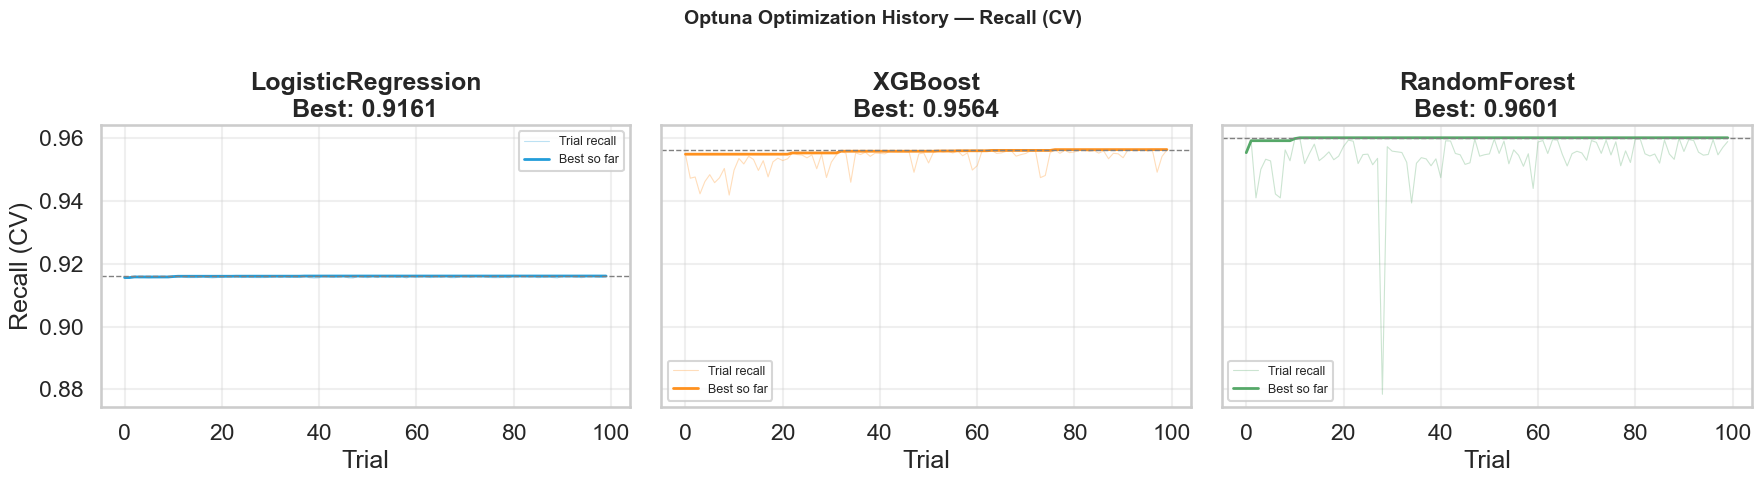

In [13]:
# Optuna optimization history — all 3 models
from optuna.visualization.matplotlib import plot_optimization_history

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
studies = ['LogisticRegression', 'XGBoost', 'RandomForest']
study_objs = [study_logreg, study_xgb, study_rf]
colors = ['#239DD9', '#FF911E', '#55a868']

for ax, name, study, color in zip(axes, studies, study_objs, colors):
    trials = [t.value for t in study.trials if t.value is not None]
    best = [max(trials[:i+1]) for i in range(len(trials))]
    ax.plot(trials, alpha=0.3, color=color, linewidth=0.8, label='Trial recall')
    ax.plot(best, color=color, linewidth=2, label='Best so far')
    ax.axhline(y=study.best_value, color='grey', linestyle='--', linewidth=1)
    ax.set_title(f'{name}\nBest: {study.best_value:.4f}', fontweight='bold')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Recall (CV)' if ax == axes[0] else '')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Optuna Optimization History — Recall (CV)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## SECTION 8 — Final Model Training & Evaluation

Trains each tuned model on the full training set and evaluates on the held-out test set.

In [14]:
from sklearn.pipeline import Pipeline

best_models = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            **best_logreg_params, class_weight='balanced', max_iter=1000, random_state=42)),
    ]),
    'XGBoost': XGBClassifier(
        **best_xgb_params, scale_pos_weight=SCALE_POS_WEIGHT,
        eval_metric='logloss', random_state=42, n_jobs=-1, tree_method='hist'),
    'RandomForest': RandomForestClassifier(
        **best_rf_params, class_weight='balanced_subsample', random_state=42, n_jobs=-1),
}

final_results = []
trained_models = {}

for name, model in best_models.items():
    # All models receive X_train_log; LogReg Pipeline scales internally
    model.fit(X_train_log, y_train)
    trained_models[name] = model
    y_prob = model.predict_proba(X_test_log)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    final_results.append({
        'model':     name,
        'accuracy':  round(accuracy_score(y_test, y_pred),  4),
        'recall':    round(recall_score(y_test, y_pred),    4),
        'precision': round(precision_score(y_test, y_pred), 4),
        'f1':        round(f1_score(y_test, y_pred),        4),
        'roc_auc':   round(roc_auc_score(y_test, y_prob),   4),
    })

eval_df = pd.DataFrame(final_results).set_index('model').sort_values('recall', ascending=False)
print('Final evaluation (default threshold=0.5, sorted by recall):')
display(eval_df.style.highlight_max(axis=0, color='#239DD9'))

Final evaluation (default threshold=0.5, sorted by recall):


,accuracy,recall,precision,f1,roc_auc
model,,,,,
RandomForest,0.886000,0.960300,0.815500,0.882000,0.970000
XGBoost,0.953500,0.956800,0.939600,0.948100,0.992400
LogisticRegression,0.896300,0.915200,0.860100,0.886800,0.968400


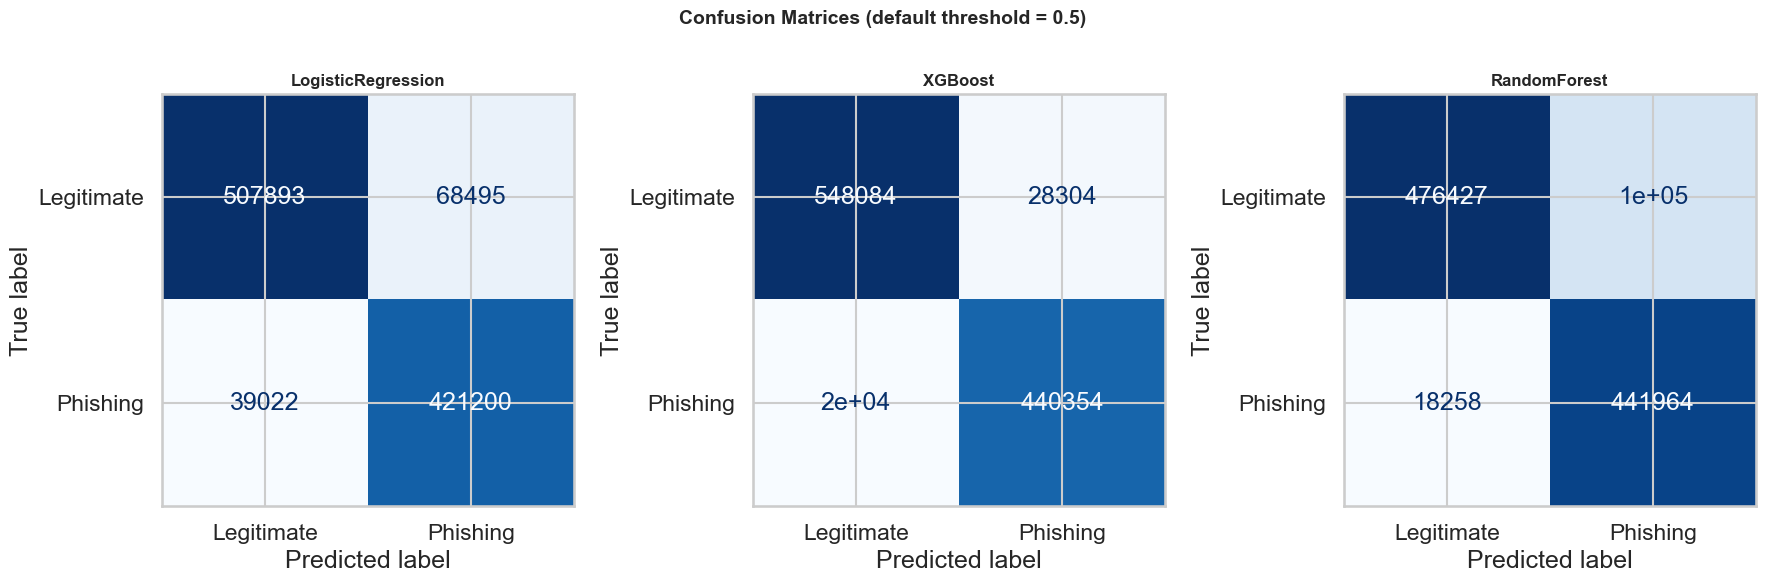

In [15]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = (model.predict_proba(X_test_log)[:, 1] >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices (default threshold = 0.5)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## SECTION 9 — Feature Importance

Visualises which features most influence each model's predictions.

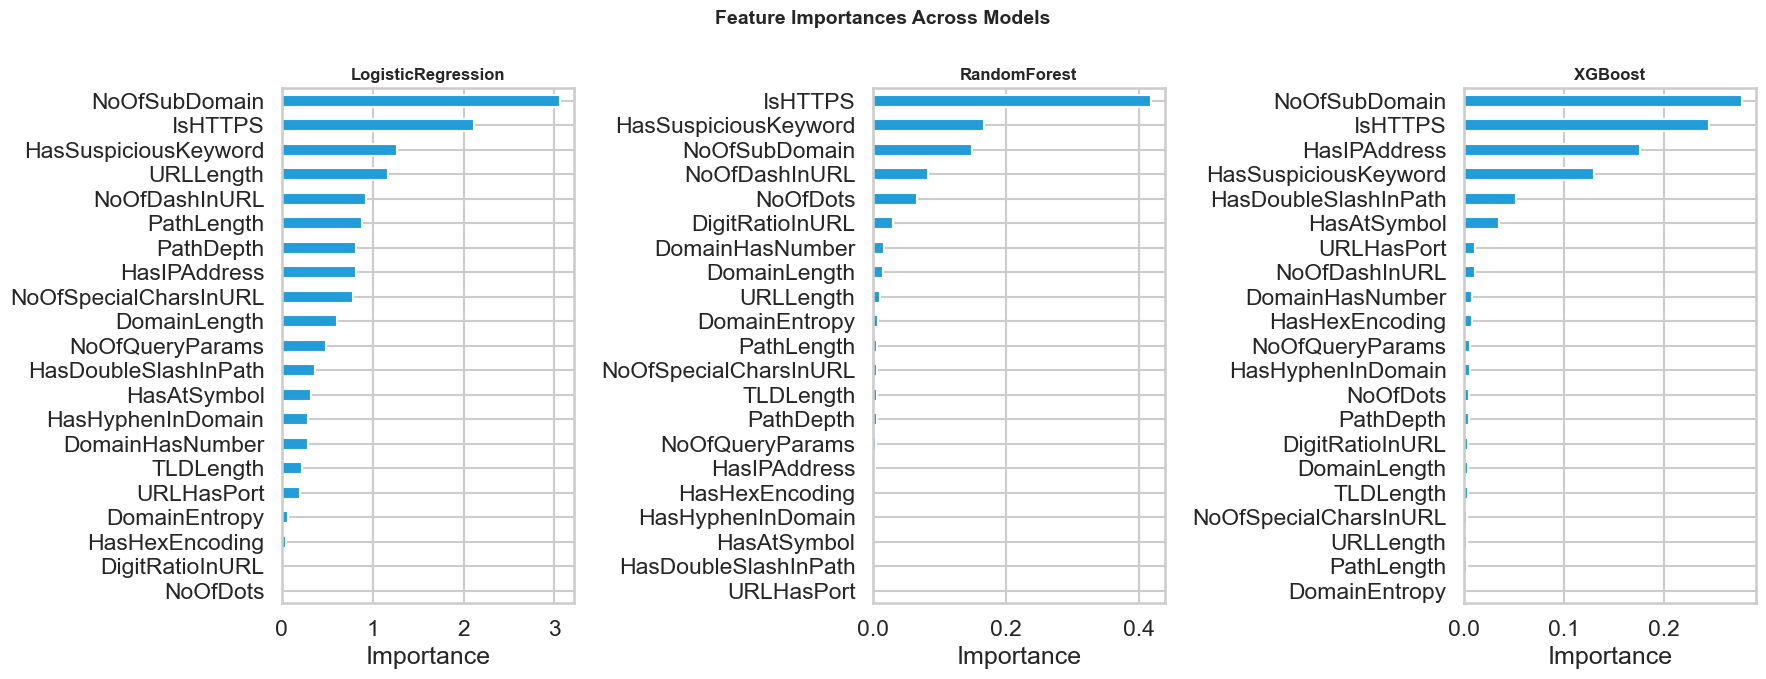

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
model_importance = {
    'LogisticRegression': np.abs(trained_models['LogisticRegression'].named_steps['clf'].coef_[0]),
    'RandomForest':       trained_models['RandomForest'].feature_importances_,
    'XGBoost':            trained_models['XGBoost'].feature_importances_,
}

for ax, (name, importance) in zip(axes, model_importance.items()):
    pd.Series(importance, index=FEATURES).sort_values().plot.barh(ax=ax, color='#239DD9')
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importances Across Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## SECTION 10 — Threshold Optimisation

The default decision threshold of 0.5 is arbitrary. By lowering it, we can push recall above 0.95 at the cost of some precision (more false alarms).

**Strategy:** for each model, sweep thresholds and find the one that maximises F1 while keeping recall ≥ 0.95. If no threshold achieves recall ≥ 0.95, select the threshold that maximises recall.

In [21]:
threshold_results = []

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test_log)[:, 1]
    prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, y_prob)

    # Among thresholds with recall >= 0.95, pick highest F1
    valid_mask = rec_arr[:-1] >= 0.95
    if valid_mask.any():
        f1_arr = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-9)
        best_idx = np.argmax(np.where(valid_mask, f1_arr, -1))
        opt_thresh = thresh_arr[best_idx]
        strategy = 'recall>=0.95, max F1'
    else:
        # Fallback: maximise recall
        best_idx = np.argmax(rec_arr[:-1])
        opt_thresh = thresh_arr[best_idx]
        strategy = 'max recall (no threshold achieves recall>=0.95)'

    y_pred_opt = (y_prob >= opt_thresh).astype(int)
    threshold_results.append({
        'model':          name,
        'opt_threshold':  round(float(opt_thresh), 4),
        'recall':         round(recall_score(y_test, y_pred_opt), 4),
        'precision':      round(precision_score(y_test, y_pred_opt), 4),
        'f1':             round(f1_score(y_test, y_pred_opt), 4),
        'roc_auc':        round(roc_auc_score(y_test, y_prob), 4),
        'strategy':       strategy,
    })

thresh_df = pd.DataFrame(threshold_results).set_index('model').sort_values('recall', ascending=False)
print('Results after threshold optimisation (sorted by recall):')
display(thresh_df.style.highlight_max(subset=['recall', 'f1', 'roc_auc'], axis=0, color='#239DD9'))

Results after threshold optimisation (sorted by recall):


,opt_threshold,recall,precision,f1,roc_auc,strategy
model,,,,,,
XGBoost,0.509500,0.955600,0.940900,0.948200,0.992400,"recall>=0.95, max F1"
LogisticRegression,0.404100,0.950000,0.827800,0.884700,0.968400,"recall>=0.95, max F1"
RandomForest,0.513500,0.950000,0.828800,0.885300,0.970000,"recall>=0.95, max F1"


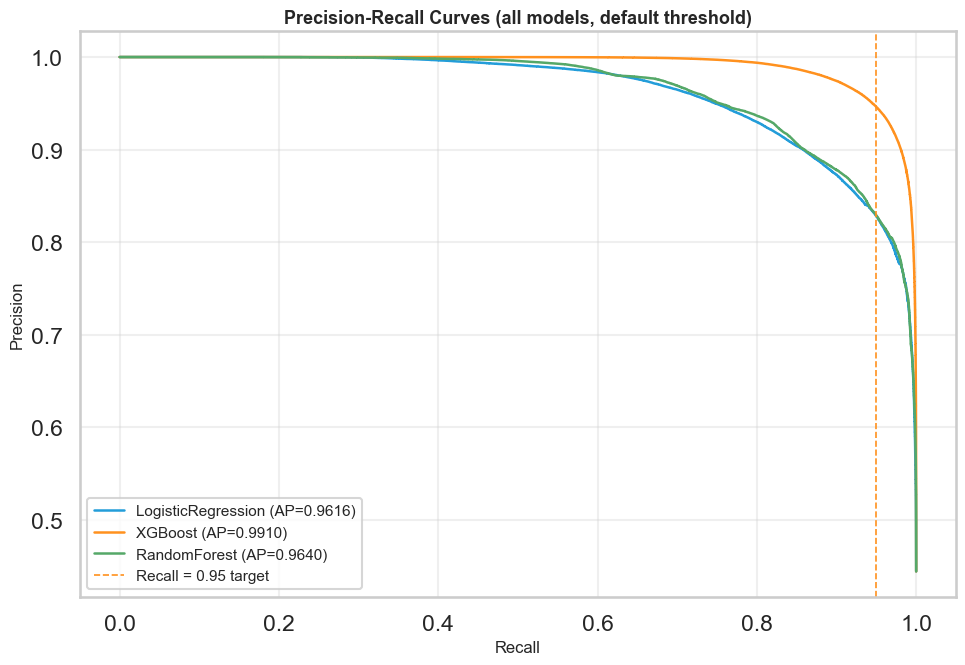

In [22]:
# Precision-Recall curve for all models
from sklearn.metrics import average_precision_score

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#239DD9', '#FF911E', '#55a868']

for (name, model), color in zip(trained_models.items(), colors):
    y_prob = model.predict_proba(X_test_log)[:, 1]
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_prob)
    auc_val = average_precision_score(y_test, y_prob)
    ax.plot(rec_arr, prec_arr, label=f'{name} (AP={auc_val:.4f})', color=color, linewidth=1.8)

ax.axvline(x=0.95, color='#FF911E', linestyle='--', linewidth=1.2, label='Recall = 0.95 target')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves (all models, default threshold)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## SECTION 11 — Stacking Ensemble

Combines all three models using a Logistic Regression meta-learner trained on their
cross-validated predictions.

The three base models are already algorithmically diverse:

| Model | Algorithm type | Characteristic |
|---|---|---|
| LogisticRegression | Linear | Low variance, calibrated probabilities |
| RandomForest | Bagging | Decorrelated trees, robust to noise |
| XGBoost | Gradient boosting | Sequential error correction, high accuracy |

Scikit-learn's `StackingClassifier` handles fold-based training automatically,
preventing data leakage into the meta-learner.

In [23]:
stack_names = ['LogisticRegression', 'RandomForest', 'XGBoost']
print('Stacking base models (algorithmically diverse):')
for name in stack_names:
    print(f'  {name:<22s}  recall={eval_df.loc[name, "recall"]:.4f}')

estimators = [(name, clone(best_models[name])) for name in stack_names]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    cv=3,
    n_jobs=-1,
    passthrough=False,
)

print('\nTraining stacking ensemble...')
stack.fit(X_train_log, y_train)
print('Done.')

Stacking base models (algorithmically diverse):
  LogisticRegression      recall=0.9152
  RandomForest            recall=0.9603
  XGBoost                 recall=0.9568

Training stacking ensemble...
Done.


In [24]:
# Evaluate stacking at default threshold and with threshold optimisation
y_prob_stack = stack.predict_proba(X_test_log)[:, 1]

# Default threshold
y_pred_default = (y_prob_stack >= 0.5).astype(int)

# Optimised threshold (recall >= 0.95)
prec_s, rec_s, thresh_s = precision_recall_curve(y_test, y_prob_stack)
valid_mask = rec_s[:-1] >= 0.95
if valid_mask.any():
    f1_s = 2 * prec_s[:-1] * rec_s[:-1] / (prec_s[:-1] + rec_s[:-1] + 1e-9)
    opt_thresh_stack = thresh_s[np.argmax(np.where(valid_mask, f1_s, -1))]
else:
    opt_thresh_stack = thresh_s[np.argmax(rec_s[:-1])]
y_pred_opt_stack = (y_prob_stack >= opt_thresh_stack).astype(int)

stack_results = pd.DataFrame([
    {'threshold': 0.5,               'recall': round(recall_score(y_test, y_pred_default), 4),
     'precision': round(precision_score(y_test, y_pred_default), 4),
     'f1':        round(f1_score(y_test, y_pred_default), 4),
     'roc_auc':   round(roc_auc_score(y_test, y_prob_stack), 4)},
    {'threshold': round(float(opt_thresh_stack), 4),
     'recall': round(recall_score(y_test, y_pred_opt_stack), 4),
     'precision': round(precision_score(y_test, y_pred_opt_stack), 4),
     'f1':        round(f1_score(y_test, y_pred_opt_stack), 4),
     'roc_auc':   round(roc_auc_score(y_test, y_prob_stack), 4)},
])
stack_results.index = ['default (0.5)', 'optimised']
print('Stacking Ensemble Performance:')
display(stack_results)

Stacking Ensemble Performance:


,threshold,recall,precision,f1,roc_auc
default (0.5),0.5000,0.9572,0.9381,0.9476,0.9913
optimised,0.5536,0.9529,0.9426,0.9477,0.9913


## SECTION 12 — Final Model Comparison

Compares all models (including stacking) after threshold optimisation.

In [25]:
# Add stacking to the final comparison
y_prob_stack = stack.predict_proba(X_test_log)[:, 1]
y_pred_stack = (y_prob_stack >= opt_thresh_stack).astype(int)

all_results = thresh_df.copy().reset_index()
all_results = all_results[['model', 'opt_threshold', 'recall', 'precision', 'f1', 'roc_auc']]
all_results = pd.concat([all_results, pd.DataFrame([{
    'model':         'Stacking',
    'opt_threshold': round(float(opt_thresh_stack), 4),
    'recall':        round(recall_score(y_test, y_pred_stack), 4),
    'precision':     round(precision_score(y_test, y_pred_stack), 4),
    'f1':            round(f1_score(y_test, y_pred_stack), 4),
    'roc_auc':       round(roc_auc_score(y_test, y_prob_stack), 4),
}])], ignore_index=True).set_index('model').sort_values('recall', ascending=False)

print('Final model comparison (all models, optimised thresholds):')
display(all_results.style.highlight_max(subset=['recall', 'f1', 'roc_auc'], axis=0, color='#239DD9'))

# Flag which models achieved recall >= 0.95
above_target = all_results[all_results['recall'] >= 0.95]
if len(above_target) > 0:
    print(f'\nModels achieving recall >= 0.95: {list(above_target.index)}')
else:
    print('\nNo model reached recall >= 0.95. Best recall:', all_results["recall"].max())

Final model comparison (all models, optimised thresholds):


,opt_threshold,recall,precision,f1,roc_auc
model,,,,,
XGBoost,0.509500,0.955600,0.940900,0.948200,0.992400
Stacking,0.553600,0.952900,0.942600,0.947700,0.991300
LogisticRegression,0.404100,0.950000,0.827800,0.884700,0.968400
RandomForest,0.513500,0.950000,0.828800,0.885300,0.970000



Models achieving recall >= 0.95: ['XGBoost', 'Stacking', 'LogisticRegression', 'RandomForest']


## SECTION 13 — Deployment Decision: Stacking vs Single Model

Selects the model to deploy in the FastAPI inference service used by the Chrome extension.

Three criteria are evaluated:
1. **Latency** — inference time per URL (must be real-time for a browser extension)
2. **Explainability** — ability to produce per-prediction human-readable explanations without LLM/DL
3. **Performance** — recall and F1 after threshold optimisation

In [26]:
# ── Latency benchmark ─────────────────────────────────────────────────────────
import time

BENCH_N = 500
bench_idx = np.random.RandomState(42).choice(len(X_test_log), BENCH_N, replace=False)
X_bench   = X_test_log.iloc[bench_idx]

latency_rows = []

for name, model in trained_models.items():
    times = []
    for j in range(BENCH_N):
        x  = X_bench.iloc[[j]]
        t0 = time.perf_counter()
        _  = model.predict_proba(x)
        times.append((time.perf_counter() - t0) * 1000)
    latency_rows.append({'Model': name, 'Type': 'Single',
                         'Mean (ms)': round(np.mean(times), 3),
                         'P95 (ms)':  round(np.percentile(times, 95), 3)})

# Stacking
times = []
for j in range(BENCH_N):
    x  = X_bench.iloc[[j]]
    t0 = time.perf_counter()
    _  = stack.predict_proba(x)
    times.append((time.perf_counter() - t0) * 1000)
latency_rows.append({'Model': 'Stacking', 'Type': 'Ensemble',
                     'Mean (ms)': round(np.mean(times), 3),
                     'P95 (ms)':  round(np.percentile(times, 95), 3)})

latency_df = pd.DataFrame(latency_rows).set_index('Model').sort_values('Mean (ms)')
print('Inference latency — single URL, 500 iterations:')
display(latency_df.style.highlight_min(subset=['Mean (ms)', 'P95 (ms)'], axis=0, color='#239DD9'))

Inference latency — single URL, 500 iterations:


,Type,Mean (ms),P95 (ms)
Model,,,
LogisticRegression,Single,0.279000,0.319000
XGBoost,Single,1.022000,1.329000
RandomForest,Single,26.048000,27.373000
Stacking,Ensemble,27.784000,29.024000


### Explainability Comparison

SHAP (SHapley Additive exPlanations) is used to generate per-prediction feature contributions.
The method available depends on the model type:

| Criterion | Single Tree Model (RF / XGBoost) | Logistic Regression | Stacking Ensemble |
|---|---|---|---|
| SHAP method | `TreeExplainer` | `LinearExplainer` | `KernelExplainer` |
| Computation | Exact Shapley values | Exact Shapley values | **Approximate** (Monte Carlo) |
| Speed | < 5 ms / URL | < 2 ms / URL | **Seconds / URL** (unusable for real-time) |
| What is explained | The model's decision directly | The model's decision directly | The **meta-learner** (indirect, less interpretable) |

**Conclusion:** Stacking cannot produce fast, exact, per-prediction explanations. Single models can.

In [27]:
# ── Performance delta: best single model vs stacking ─────────────────────────
single_res = all_results.drop('Stacking', errors='ignore')
deploy_name = single_res['recall'].idxmax()

metrics = ['recall', 'precision', 'f1', 'roc_auc']
perf_compare = pd.DataFrame({
    deploy_name: all_results.loc[deploy_name, metrics],
    'Stacking':  all_results.loc['Stacking',  metrics],
}).T
perf_compare['recall_delta'] = perf_compare['recall'] - perf_compare.loc[deploy_name, 'recall']

print('Performance comparison — best single model vs stacking:')
display(perf_compare.round(4))

Performance comparison — best single model vs stacking:


,recall,precision,f1,roc_auc,recall_delta
XGBoost,0.9556,0.9409,0.9482,0.9924,0.0000
Stacking,0.9529,0.9426,0.9477,0.9913,-0.0027


### Deployment Decision

| Criterion | Winner | Note |
|---|---|---|
| Latency | **Single model** | Stacking calls 3 models sequentially |
| Explainability | **Single model** | Exact SHAP; stacking needs KernelExplainer (slow + approximate) |
| Recall | Marginal difference | Stacking may edge ahead by < 0.01 — not worth the trade-offs |

**→ The best single model (by recall) is selected for deployment.**

In [46]:
# ── SHAP explanation demo ─────────────────────────────────────────────────────
import shap

deploy_model_demo = trained_models[deploy_name]

# Handle Pipeline (LogReg) vs raw tree model
if hasattr(deploy_model_demo, 'named_steps'):
    # LogisticRegression inside Pipeline
    clf_step    = deploy_model_demo.named_steps['clf']
    scaler_step = deploy_model_demo.named_steps['scaler']
    bg_scaled   = pd.DataFrame(
        scaler_step.transform(X_train_log.sample(n=100, random_state=42)),
        columns=FEATURES)
    explainer_demo = shap.LinearExplainer(clf_step, bg_scaled)
    def get_shap_input(X):
        return pd.DataFrame(scaler_step.transform(X), columns=FEATURES, index=X.index)
else:
    explainer_demo = shap.TreeExplainer(deploy_model_demo)
    def get_shap_input(X): return X

# Pick 1 phishing + 1 legitimate sample
phish_idx = y_test[y_test == 1].index[0]
legit_idx = y_test[y_test == 0].index[0]
demo_X    = X_test_log.loc[[phish_idx, legit_idx]]
demo_y    = y_test.loc[[phish_idx, legit_idx]]

sv = explainer_demo.shap_values(get_shap_input(demo_X))
if isinstance(sv, list): sv = sv[1]

print(f'Deployment model: {deploy_name}')
print(f'Optimised threshold: {thresh_df.loc[deploy_name, "opt_threshold"]:.4f}')
print()

FEATURE_TEMPLATES_PHISHING = {
    'HasSuspiciousKeyword': lambda v: "Contains a suspicious keyword (e.g. 'login', 'verify', 'secure', 'bank')" if v else None,
    'HasIPAddress':         lambda v: "Uses a raw IP address instead of a proper domain name" if v else None,
    'URLLength':            lambda v: f"Unusually long URL ({v:.0f} chars) — hides the real destination" if v > 75 else None,
    'IsHTTPS':              lambda v: "Does not use HTTPS encryption" if not v else None,
    'HasHyphenInDomain':    lambda v: "Domain contains hyphens — common in lookalike phishing domains" if v else None,
    'DomainHasNumber':      lambda v: "Domain name contains digits, uncommon for legitimate brands" if v else None,
    'DomainEntropy':        lambda v: f"Domain appears algorithmically generated (entropy {v:.2f})" if v > 3.5 else None,
    'NoOfSubDomain':        lambda v: f"Deep subdomain chain ({int(v)} levels) disguises the real domain" if v > 2 else None,
    'HasAtSymbol':          lambda v: "Contains '@' — used to trick browsers into ignoring the real domain" if v else None,
    'HasDoubleSlashInPath': lambda v: "Path contains '//' — a known obfuscation technique" if v else None,
    'URLHasPort':           lambda v: "Specifies a non-standard port number" if v else None,
    'HasHexEncoding':       lambda v: "URL contains hex-encoded characters (%xx) to hide content" if v else None,
    'NoOfQueryParams':      lambda v: f"High number of query parameters ({int(v)})" if v > 5 else None,
    'PathDepth':            lambda v: f"Very deep path structure ({int(v)} levels)" if v > 5 else None,
    'DigitRatioInURL':      lambda v: f"High digit ratio ({v*100:.1f}%) — may be auto-generated" if v > 0.2 else None,
    'NoOfSpecialCharsInURL':lambda v: f"Many special characters ({int(v)}) — typical of obfuscated URLs" if v > 15 else None,
    'NoOfDots':             lambda v: f"Many dots ({int(v)}) — deep subdomain or path nesting" if v > 5 else None,
    'NoOfDashInURL':        lambda v: f"Many dashes ({int(v)}) — common in lookalike domain names" if v > 4 else None,
    'TLDLength':            lambda v: f"Unusual top-level domain length ({int(v)} chars)" if v > 4 else None,
    'PathLength':           lambda v: f"Very long URL path ({int(v)} chars)" if v > 100 else None,
}
FEATURE_TEMPLATES_LEGIT = {
    'HasSuspiciousKeyword': lambda v: "No suspicious keywords detected in the URL" if not v else None,
    'HasIPAddress':         lambda v: "Uses a proper registered domain name" if not v else None,
    'IsHTTPS':              lambda v: "Uses HTTPS encryption" if v else None,
    'HasHyphenInDomain':    lambda v: "Clean domain name with no hyphens" if not v else None,
    'DomainEntropy':        lambda v: f"Domain name appears natural (entropy {v:.2f})" if v <= 3.5 else None,
    'NoOfSubDomain':        lambda v: "Simple, clean subdomain structure" if v <= 1 else None,
    'HasAtSymbol':          lambda v: "No '@' symbol in URL" if not v else None,
    'HasHexEncoding':       lambda v: "No hidden hex encoding in URL" if not v else None,
    'URLHasPort':           lambda v: "Uses standard port (no explicit port in URL)" if not v else None,
    'URLLength':            lambda v: f"Normal URL length ({v:.0f} chars)" if v <= 75 else None,
    'DomainHasNumber':      lambda v: "Domain name contains no digits" if not v else None,
}

def generate_reasons(shap_row, feat_vals, features, is_phishing, top_n=4):
    templates = FEATURE_TEMPLATES_PHISHING if is_phishing else FEATURE_TEMPLATES_LEGIT
    direction = +1 if is_phishing else -1
    scored = [(features[j], direction * shap_row[j], feat_vals[j])
              for j in range(len(features)) if direction * shap_row[j] > 0]
    scored.sort(key=lambda x: x[1], reverse=True)
    reasons = []
    for feat, _, val in scored:
        fn = templates.get(feat)
        if fn:
            r = fn(val)
            if r: reasons.append(r)
        if len(reasons) == top_n:
            break
    return reasons or ['No dominant features identified']

for row_i, (idx, label) in enumerate(zip([phish_idx, legit_idx], [1, 0])):
    prob      = deploy_model_demo.predict_proba(demo_X.iloc[[row_i]])[0, 1]
    threshold = thresh_df.loc[deploy_name, 'opt_threshold']
    is_phish  = prob >= threshold
    raw_vals = np.expm1(X_test_log.loc[idx].values)

    confidence = (1 - prob) * 100 if not is_phish else prob * 100
    print(f"{'⚠️   PHISHING' if is_phish else '✅  LEGITIMATE'}  "
        f"(confidence: {confidence:.1f}%  |  threshold: {threshold:.3f})")

Deployment model: XGBoost
Optimised threshold: 0.5095

⚠️   PHISHING  (confidence: 96.5%  |  threshold: 0.509)
✅  LEGITIMATE  (confidence: 100.0%  |  threshold: 0.509)


## SECTION 14 — Model Persistence

Saves the best-performing model (by recall after threshold optimisation) together with the scaler and optimal threshold so inference is fully reproducible.

In [47]:
# ── Select best single model for deployment ──────────────────────────────────
single_results = all_results.drop('Stacking', errors='ignore')
deploy_name   = single_results['recall'].idxmax()
deploy_recall = single_results.loc[deploy_name, 'recall']
stack_recall  = all_results.loc['Stacking', 'recall'] if 'Stacking' in all_results.index else None

print(f'Deployment model : {deploy_name}')
print(f'Recall           : {deploy_recall:.4f}')
if stack_recall:
    print(f'Stacking recall  : {stack_recall:.4f}  (delta: {deploy_recall - stack_recall:+.4f})')

# Re-fit on full training data
deploy_model    = clone(best_models[deploy_name])
deploy_model.fit(X_train_log, y_train)
deploy_threshold = float(thresh_df.loc[deploy_name, 'opt_threshold'])

out_dir = Path('models')
out_dir.mkdir(exist_ok=True)
import datetime
ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

model_path = out_dir / f'deploy_{deploy_name}_{ts}.pkl'
import joblib
joblib.dump({
    'model':           deploy_model,    # Pipeline for LogReg (scaler inside), raw model for trees
    'model_name':      deploy_name,
    'features':        FEATURES,
    'threshold':       deploy_threshold,
    'skewed_features': list(skewed_features),
}, model_path)

print(f'\nSaved bundle to: {model_path}')
print('Bundle: model (Pipeline if LogReg), model_name, features, threshold, skewed_features')

Deployment model : XGBoost
Recall           : 0.9556
Stacking recall  : 0.9529  (delta: +0.0027)

Saved bundle to: models/deploy_XGBoost_20260404_104433.pkl
Bundle: model (Pipeline if LogReg), model_name, features, threshold, skewed_features
